# HW 2 Analysis and Figures - Notebook 2

This notebook analyzes processed SNOTEL and USGS streamflow data for the Starvation Reservoir basin. It develops figures to evaluate snowpack conditions, monthly streamflow variability, and relationships between peak SWE and inflow. These results are used to inform reservoir management recommendations for April 1, 2025.

### Imports and load data

In [32]:
import numpy as np

# Load data
swe = pd.read_csv("data/swe.csv", parse_dates=["date"])
flow = pd.read_csv("data/flow.csv", parse_dates=["date"])
monthly = pd.read_csv("data/monthly.csv")
peak = pd.read_csv("data/peak_swe.csv")

# Quick check
swe.head()

,date,swe,wy
0,1980-01-01,362.17,1980
1,1980-01-02,362.17,1980
2,1980-01-03,362.17,1980
3,1980-01-04,362.17,1980
4,1980-01-05,375.75,1980


### Add Water Year + DOWY (SWE)

In [15]:
# Water year
swe["wy"] = swe["date"].dt.year
swe.loc[swe["date"].dt.month >= 10, "wy"] += 1

# Day of water year
start = pd.to_datetime(swe["wy"] - 1, format="%Y") + pd.DateOffset(months=9)
swe["dowy"] = (swe["date"] - start).dt.days + 1

### SWE Climatology Plot

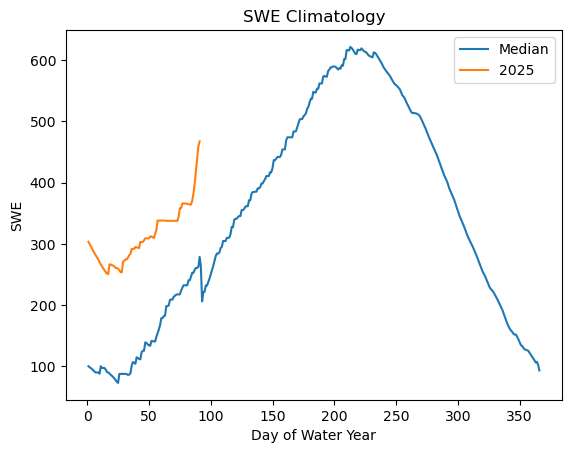

In [16]:
# Median SWE by DOWY
median_swe = swe.groupby("dowy")["swe"].median()

# Select a year (ex: 2025)
yr = 2025
yr_swe = swe[swe["wy"] == yr]

# Plot
plt.figure()
plt.plot(median_swe.index, median_swe.values, label="Median")
plt.plot(yr_swe["dowy"], yr_swe["swe"], label=str(yr))
plt.xlabel("Day of Water Year")
plt.ylabel("SWE")
plt.title("SWE Climatology")
plt.legend()
plt.show()

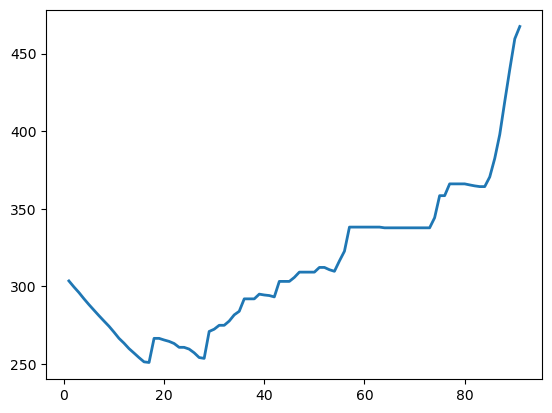

In [38]:
plt.plot(yr_swe["dowy"], yr_swe["swe"], linewidth=2, label="2025 (partial)")

### Monthly Flow Distribution

In [22]:
monthly.columns

Index(['wy', 'month', 'vol'], dtype='str')

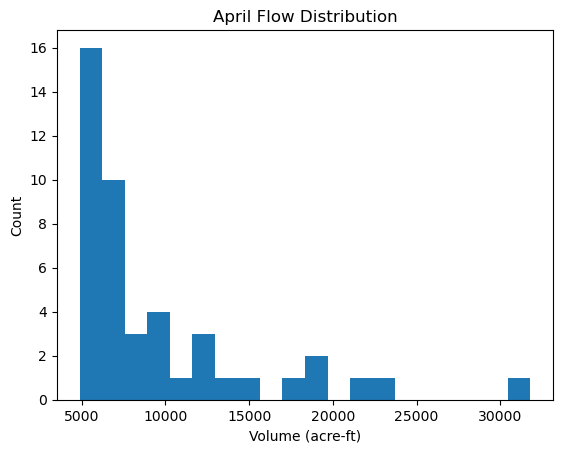

In [23]:
apr = monthly[monthly["month"] == 4]

plt.figure()
plt.hist(apr["vol"], bins=20)
plt.xlabel("Volume (acre-ft)")
plt.ylabel("Count")
plt.title("April Flow Distribution")
plt.show()

### Peak SWE vs Flow

In [24]:
# Merge peak SWE with flow
df = peak.merge(monthly, on="wy")

df.head()

,wy,swe,month,vol
0,1981,791.15,1,5668.75726
1,1981,791.15,2,4819.83210
2,1981,791.15,3,5347.43512
3,1981,791.15,4,6880.65743
4,1981,791.15,5,9062.47443


### Scatter Plot (Key Result)

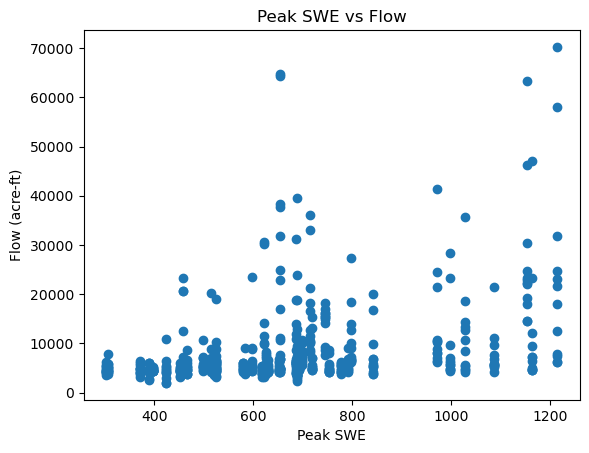

In [30]:
plt.figure()
plt.scatter(df["swe"], df["vol"])
plt.xlabel("Peak SWE")
plt.ylabel("Flow (acre-ft)")
plt.title("Peak SWE vs Flow")
plt.show()

### Adding Trend Line

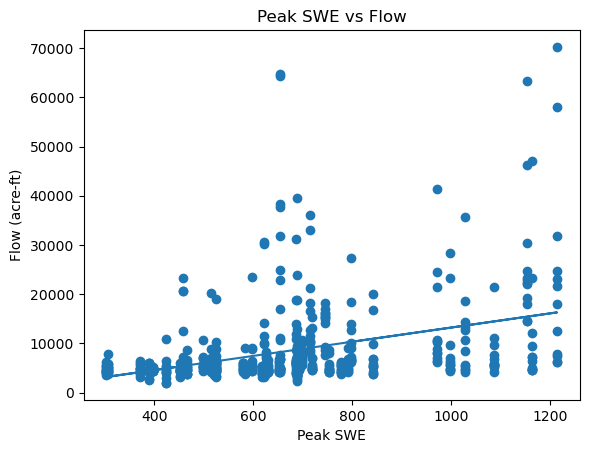

In [34]:
# Fit line
m, b = np.polyfit(df["swe"], df["vol"], 1)

plt.figure()
plt.scatter(df["swe"], df["vol"])
plt.plot(df["swe"], m*df["swe"] + b)

plt.xlabel("Peak SWE")
plt.ylabel("Flow (acre-ft)")
plt.title("Peak SWE vs Flow")
plt.show()